In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
from collections import Counter
from nltk.util import ngrams

pd.set_option('display.max_colwidth', None)

# stopwords for portuguese language
stopwords_pt = set(stopwords.words('portuguese'))
custom_stopwords = {
    'bom', 'dia', 'boa', 'tarde', 'noite', 'olá', 'tudo', 'bem',
    'obrigado', 'obrigada', 'agradeço', 'graças', 'deus', 'feliz',
    'vídeo', 'video', 'canal', 'comentário', 'pode', 'posso', 'devo',
    'fazer', 'faz', 'fiz', 'vou', 'vai', 'saber', 'sei', 'queria', 'quero',
    'ajudar', 'ajuda', 'esclarecer', 'tirar', 'ter', 'deu', 'fiquei',
    'sempre', 'ainda', 'agora', 'aqui', 'assim', 'porque', 'pra', 'pro',
    'qualquer', 'alguma', 'algum', 'alguém', 'todo', 'todos', 'outra', 'outro',
    'quanto', 'quantos', 'muita', 'pouco', 'nada', 'coisa', 'disposição'
}
stopwords_pt.update(custom_stopwords)

# ingestion path
DATA_PATH = '../data/results/extracted_question/relevant_question_extraction_gpt-5-4-mini_high_flex.csv'

# output path
FIGS_PATH = '../data/figs/'

In [2]:
def plot_wordcloud(texts: str, title: str='', save_path: str=''):
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=stopwords_pt,
        min_word_length=3
    ).generate(texts)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')
    plt.savefig(save_path)
    plt.show()

def plot_bigram_wordcloud(texts: str, title: str='', save_path: str=''):
    words = re.findall(r'[a-záãâéêíóôõúç]+', texts.lower())
    
    filtered_words = [w for w in words if w not in stopwords_pt and len(w) >= 3]
    
    bigram_list = list(ngrams(filtered_words, 2))
    bigram_counts = Counter(bigram_list)
    frequencies = {' '.join(k): v for k, v in bigram_counts.items()}
    
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
    ).generate_from_frequencies(frequencies)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')
    plt.savefig(save_path)
    plt.show()

In [8]:
df = pd.read_csv(DATA_PATH)
df = df[df['perguntas'] == '[]']
comments_text = ' '.join(df['comentario'])
df.sample(5)

,comment_id,comentario,titulo,comentario_pai,perguntas
29316,UgzQQQ9yIGues_yUjj94AaABAg.AErTIuClCfvAErU8hZdHhH,Segue essa minha dica de consultora que vai da muito certo por aí! Ninguem fala sobre isso né?,Essa BOMBA tem um segredo para funcionar. E eu vou te mostrar!,"Nossa, achei super diferente essa sua dica de colocar a bomba logo na maior força que a mãe aguentar. Todos os vídeos que vi sobre essa bomba, foram justamente ao contrário. Começar da massagem para o maior nível. Eu gostaria sim de um vídeo completão sobre a bomba e seu uso.",[]
3737,Ugyt64l-0ZqJXF68-Wd4AaABAg,Outra dúvida: por que que isso é alarmantemente comum nas mulheres?,Estrias na Pele 😱#medicina #medico #enfermagem #enfermeiro #enfermeira #dermatologia #dermatologista,NaN,[]
6608,UgyEo8H3gkIvOLjKuxV4AaABAg,Ou 31 de janeiro,TEMOS A DATA QUE A OLÍVIA VAI NASCER 😭🩷 #paidemenina #gravidez #portugal,NaN,[]
26655,UgxCK2vZIfAqs_RNe-14AaABAg,"Lala, o que você tem a dizer sobre o aparelho V12? É bom para abdômen?",Isso que Acontece com seu CORPO se fizer ABDOMINAL Todo Dia,NaN,[]
22066,UgzJiMrWsfCHnD5U3pB4AaABAg,Qual final personagens Leandra leal em personagens em Passione 2010/2011,JÉSSICA ENTRA EM TRABALHO DE PARTO NO ALTAR | PASSIONE | CENAS MARCANTES,NaN,[]


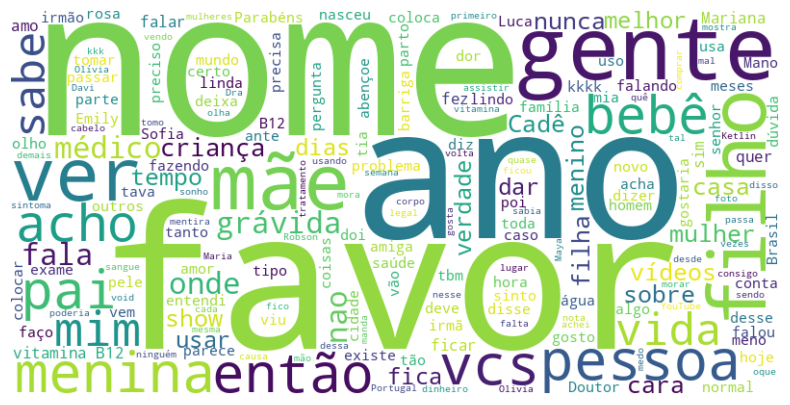

In [4]:
plot_wordcloud(comments_text, save_path=FIGS_PATH + 'wordcloud_no_questions.png')

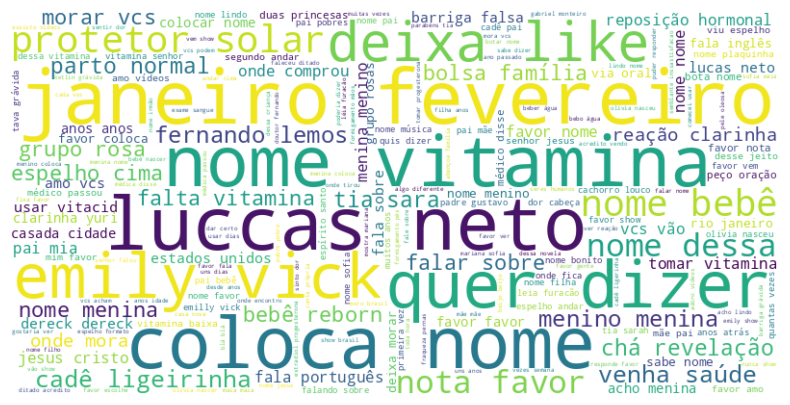

In [5]:
plot_bigram_wordcloud(comments_text, save_path=FIGS_PATH + 'bigram_wordcloud_no_questions.png')